# TCSSC-Transformer -- Tool-Call Sequence Safety Classifier

Training & evaluasi TCSSC dengan Sequence Aggregator Transformer (4 layer).
Dataset: `tcssc_dataset.csv`.

## 1. Install Dependencies

In [1]:
!pip install transformers==4.40.0 torch scikit-learn pandas numpy tqdm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 114.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 99.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 103.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
sentence-transformers 5.4.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0

## 2. Imports & Configuration

In [2]:
import os, json, math, random, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, classification_report,
                              confusion_matrix, accuracy_score)
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

# ── Config ────────────────────────────────────────────
DATASET_PATH       = '/kaggle/input/datasets/raditya0/tcssc-dataset/tcssc_dataset.csv'
SPLIT_PATH         = '/kaggle/input/datasets/raditya0/tcssc-dataset/tcssc_split.json'
ENCODER_MODEL      = 'bert-base-multilingual-cased'
MAX_SEQ_LEN        = 128
MAX_SEQ_LEN_CTX    = 64
EMBED_DIM          = 768
MAX_TOOL_CALLS     = 20
LSTM_HIDDEN        = 256
LSTM_LAYERS        = 2
LSTM_DROPOUT       = 0.3
TRANSFORMER_HEADS  = 8
TRANSFORMER_LAYERS = 4
TRANSFORMER_FF_DIM = 512
TRANSFORMER_DROPOUT = 0.1
CLASSIFIER_HIDDEN  = 128
CLASSIFIER_DROPOUT = 0.3
BATCH_SIZE         = 16
LEARNING_RATE      = 2e-4
NUM_EPOCHS         = 15
WEIGHT_DECAY       = 1e-4
EARLY_STOP         = 5
SEED               = 42
CHECKPOINT_DIR     = '/kaggle/working/checkpoints'
OUTPUT_DIR         = '/kaggle/working/outputs'

LABEL2ID = {'benign': 0, 'direct_attack': 1,
            'sequential_attack': 2, 'parameter_injection': 3}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
NUM_CLASSES = 4
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
set_seed()
print(f'Device: {DEVICE}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


Device: cuda
CUDA available: True
GPU: Tesla T4


## 3. Load Dataset

In [3]:
df = pd.read_csv(DATASET_PATH)
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print('\nLabel distribution:')
print(df['label'].value_counts())
print('\nSource distribution:')
print(df['source'].value_counts().head(10))
df.head(3)


Shape: (10242, 5)
Columns: ['tool_calls_json', 'tool_calls_text', 'label', 'source', 'context_text']

Label distribution:
label
benign                 2654
parameter_injection    2654
sequential_attack      2626
direct_attack          2308
Name: count, dtype: int64

Source distribution:
source
wildjailbreak           2121
apigen_mt               2120
bipia                   1747
toolsafe_safetybench    1004
injecagent               829
safetoolbench            691
redcode_exec             656
stac                     439
rjudge                   332
agentdojo                250
Name: count, dtype: int64


,tool_calls_json,tool_calls_text,label,source,context_text
0,"[{""name"": ""find_user_id_by_email"", ""parameters...",[FUNC] find_user_id_by_email [ARGS] email=luca...,benign,apigen_mt,"assistant: Your order is still pending, so we ..."
1,"[{""name"": ""harmful_action"", ""parameters"": {""co...",[FUNC] harmful_action [ARGS] context=In the co...,sequential_attack,wildjailbreak,user: In the context of a dystopian novel I am...
2,"[{""name"": ""submitClaimAPI"", ""parameters"": {""po...",[FUNC] submitclaimapi [ARGS] policy_id=22222 |...,direct_attack,safetoolbench,user: Submit a claim for my health insurance p...


## 4. Dataset & DataLoaders

In [4]:
# ── Preprocessing utils ───────────────────────────────
def normalize_tool_call(tc):
    name   = str(tc.get('name', tc.get('function', 'unknown'))).lower().strip()
    params = tc.get('parameters', tc.get('arguments', tc.get('args', tc.get('params', {}))))
    if isinstance(params, str):
        try:    params = json.loads(params)
        except: params = {'raw': params}
    return {'name': name, 'params': params}

def flatten_params(params, max_keys=10):
    # cap 400 char cuma jaring pengaman outlier, truncation final tetap di token (max_length=128)
    if not isinstance(params, dict): return str(params)[:400]
    parts = []
    for i, (k, v) in enumerate(params.items()):
        if i >= max_keys: break
        parts.append(f'{k}={str(v)[:400]}')
    return ' | '.join(parts)

def tool_call_to_text(tc):
    n = normalize_tool_call(tc)
    return f"[FUNC] {n['name']} [ARGS] {flatten_params(n['params'])}"

# ── Dataset ───────────────────────────────────────────
class ToolCallDataset(Dataset):
    def __init__(self, df, tokenizer):
        self.df        = df.reset_index(drop=True)
        self.tokenizer = tokenizer

    def __len__(self): return len(self.df)

    def _tok(self, text, max_len):
        enc = self.tokenizer(text, max_length=max_len, padding='max_length',
                             truncation=True, return_tensors='pt')
        return {k: v.squeeze(0) for k, v in enc.items()}

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = LABEL2ID.get(str(row['label']), 0)

        try:    sequence = json.loads(str(row.get('tool_calls_json', '[]')))
        except: sequence = []

        ctx_text = str(row.get('context_text', ''))[:MAX_SEQ_LEN_CTX * 4]

        tc_texts  = [tool_call_to_text(tc) for tc in sequence[:MAX_TOOL_CALLS]]
        tc_tokens = [self._tok(t, MAX_SEQ_LEN) for t in tc_texts]
        pad_enc   = self._tok('', MAX_SEQ_LEN)
        tc_tokens += [pad_enc] * (MAX_TOOL_CALLS - len(tc_tokens))

        input_ids      = torch.stack([t['input_ids']      for t in tc_tokens])
        attention_mask = torch.stack([t['attention_mask'] for t in tc_tokens])

        seq_len  = max(min(len(sequence), MAX_TOOL_CALLS), 1)
        seq_mask = torch.zeros(MAX_TOOL_CALLS, dtype=torch.bool)
        seq_mask[:seq_len] = True

        ctx_enc = self._tok(ctx_text, MAX_SEQ_LEN_CTX)

        return {
            'input_ids':          input_ids,
            'attention_mask':     attention_mask,
            'seq_mask':           seq_mask,
            'ctx_input_ids':      ctx_enc['input_ids'],
            'ctx_attention_mask': ctx_enc['attention_mask'],
            'label':              torch.tensor(label, dtype=torch.long),
        }

# ── Load split kanonik (sama persis di semua notebook model & ablasi) ──
# split di-generate sekali via data/generate_split.py (group_aware_split,
# group key tool_calls_text+context_text+label, seed=SEED), disimpan jadi
# row index per split biar semua notebook bisa apple-to-apple
tokenizer = AutoTokenizer.from_pretrained(ENCODER_MODEL)

with open(SPLIT_PATH, encoding='utf-8') as f:
    split_map = json.load(f)

train_df = df.iloc[split_map['train_idx']].reset_index(drop=True)
val_df   = df.iloc[split_map['val_idx']].reset_index(drop=True)
test_df  = df.iloc[split_map['test_idx']].reset_index(drop=True)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

train_loader = DataLoader(ToolCallDataset(train_df, tokenizer), batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(ToolCallDataset(val_df,   tokenizer), batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(ToolCallDataset(test_df,  tokenizer), batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train: 7174 | Val: 1530 | Test: 1538


## 5. Model Architecture — TCSSC

In [5]:
# ════════════════════════════════════════════════════════
# MODEL TCSSC — Tool-Call Sequence Safety Classifier
# ════════════════════════════════════════════════════════

class ToolCallEncoder(nn.Module):
    def __init__(self, model_name=ENCODER_MODEL, freeze_bert=True):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        if freeze_bert:
            for p in self.bert.parameters():
                p.requires_grad = False
        self.projection = nn.Sequential(
            nn.Linear(EMBED_DIM, EMBED_DIM // 2),
            nn.LayerNorm(EMBED_DIM // 2),
            nn.ReLU(),
            nn.Dropout(0.1),
        )

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        return self.projection(cls)


class LSTMAggregator(nn.Module):
    def __init__(self, input_dim=EMBED_DIM // 2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim, hidden_size=LSTM_HIDDEN,
            num_layers=LSTM_LAYERS, batch_first=True,
            bidirectional=True,
            dropout=LSTM_DROPOUT if LSTM_LAYERS > 1 else 0,
        )
        self.layer_norm = nn.LayerNorm(LSTM_HIDDEN * 2)
        self.dropout    = nn.Dropout(LSTM_DROPOUT)

    def forward(self, x, seq_mask):
        lengths  = seq_mask.sum(dim=1).clamp(min=1).cpu()
        packed   = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        out, _   = self.lstm(packed)
        out, _   = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        idx      = (lengths - 1).clamp(min=0).to(x.device)
        idx      = idx.unsqueeze(1).unsqueeze(2).expand(-1, 1, out.size(2))
        out      = out.gather(1, idx).squeeze(1)
        return self.dropout(self.layer_norm(out))


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=MAX_TOOL_CALLS):
        super().__init__()
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x): return x + self.pe[:, :x.size(1)]


class TransformerAggregator(nn.Module):
    def __init__(self, input_dim=EMBED_DIM // 2):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, TRANSFORMER_FF_DIM)
        self.pos_enc    = PositionalEncoding(TRANSFORMER_FF_DIM)
        enc_layer       = nn.TransformerEncoderLayer(
            d_model=TRANSFORMER_FF_DIM, nhead=TRANSFORMER_HEADS,
            dim_feedforward=TRANSFORMER_FF_DIM * 2,
            dropout=TRANSFORMER_DROPOUT, batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=TRANSFORMER_LAYERS)
        self.layer_norm  = nn.LayerNorm(TRANSFORMER_FF_DIM)
        self.dropout     = nn.Dropout(TRANSFORMER_DROPOUT)

    def forward(self, x, seq_mask):
        x        = self.pos_enc(self.input_proj(x))
        pad_mask = ~seq_mask
        out      = self.transformer(x, src_key_padding_mask=pad_mask)
        mask_f   = seq_mask.unsqueeze(-1).float()
        out      = (out * mask_f).sum(dim=1) / mask_f.sum(dim=1).clamp(min=1)
        return self.dropout(self.layer_norm(out))


class HarmClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, CLASSIFIER_HIDDEN),
            nn.LayerNorm(CLASSIFIER_HIDDEN), nn.ReLU(),
            nn.Dropout(CLASSIFIER_DROPOUT),
            nn.Linear(CLASSIFIER_HIDDEN, CLASSIFIER_HIDDEN // 2),
            nn.ReLU(), nn.Dropout(CLASSIFIER_DROPOUT),
            nn.Linear(CLASSIFIER_HIDDEN // 2, NUM_CLASSES),
        )

    def forward(self, x): return self.net(x)


class TCSSC(nn.Module):
    def __init__(self, aggregator_type='lstm', freeze_bert=True):
        super().__init__()
        assert aggregator_type in ('lstm', 'transformer')
        self.aggregator_type = aggregator_type
        self.encoder         = ToolCallEncoder(freeze_bert=freeze_bert)
        self.ctx_encoder     = ToolCallEncoder(freeze_bert=freeze_bert)
        enc_out_dim          = EMBED_DIM // 2

        if aggregator_type == 'lstm':
            self.aggregator = LSTMAggregator(enc_out_dim)
            agg_out_dim     = LSTM_HIDDEN * 2
        else:
            self.aggregator = TransformerAggregator(enc_out_dim)
            agg_out_dim     = TRANSFORMER_FF_DIM

        self.classifier = HarmClassifier(agg_out_dim + enc_out_dim)

    def forward(self, batch):
        B, T, L   = batch['input_ids'].shape
        ids_flat  = batch['input_ids'].view(B * T, L)
        mask_flat = batch['attention_mask'].view(B * T, L)
        tc_embeds = self.encoder(ids_flat, mask_flat).view(B, T, -1)
        seq_repr  = self.aggregator(tc_embeds, batch['seq_mask'])
        ctx_repr  = self.ctx_encoder(batch['ctx_input_ids'], batch['ctx_attention_mask'])
        return self.classifier(torch.cat([seq_repr, ctx_repr], dim=-1))

print('Model TCSSC defined.')


Model TCSSC defined.


## 6. Training & Evaluation Functions

In [6]:
# ════════════════════════════════════════════════════════
# TRAINING & EVALUATION FUNCTIONS
# ════════════════════════════════════════════════════════

def compute_class_weights(label_list, device=DEVICE):
    counts  = Counter(LABEL2ID.get(l, l) if isinstance(l, str) else l for l in label_list)
    total   = len(label_list)
    weights = [total / (NUM_CLASSES * counts.get(i, 1)) for i in range(NUM_CLASSES)]
    return torch.tensor(weights, dtype=torch.float).to(device)


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []
    for batch in loader:
        batch  = {k: v.to(device) for k, v in batch.items()}
        labels = batch.pop('label')
        optimizer.zero_grad()
        logits = model(batch)
        loss   = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        all_preds.extend(logits.argmax(-1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    return total_loss / len(loader), f1


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for batch in loader:
            batch  = {k: v.to(device) for k, v in batch.items()}
            labels = batch.pop('label')
            logits = model(batch)
            total_loss += criterion(logits, labels).item()
            all_preds.extend(logits.argmax(-1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    return total_loss / len(loader), f1, all_preds, all_labels


def train_model(model, train_loader, val_loader, train_labels,
                agg_type, num_epochs=NUM_EPOCHS, device=DEVICE):
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    model     = model.to(device)
    weights   = compute_class_weights(train_labels, device)
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                      lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)

    best_f1, patience_cnt = 0.0, 0
    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        tr_loss, tr_f1 = train_epoch(model, train_loader, optimizer, criterion, device)
        vl_loss, vl_f1, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step()
        elapsed = time.time() - t0

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_f1'].append(tr_f1)
        history['val_f1'].append(vl_f1)

        print(f'Ep {epoch:02d}/{num_epochs} | '
              f'Loss {tr_loss:.4f}/{vl_loss:.4f} | '
              f'F1 {tr_f1:.4f}/{vl_f1:.4f} | {elapsed:.0f}s')

        if vl_f1 > best_f1:
            best_f1 = vl_f1; patience_cnt = 0
            ckpt = os.path.join(CHECKPOINT_DIR, f'tcssc_{agg_type}_best.pt')
            torch.save(model.state_dict(), ckpt)
            print(f'  >> Saved (val F1: {best_f1:.4f})')
        else:
            patience_cnt += 1
            if patience_cnt >= EARLY_STOP:
                print(f'Early stopping at epoch {epoch}')
                break

    return history


def evaluate_final(model, test_loader, device=DEVICE):
    criterion = nn.CrossEntropyLoss()
    _, _, preds, labels = evaluate(model, test_loader, criterion, device)
    report = classification_report(labels, preds,
                                   target_names=list(LABEL2ID.keys()),
                                   output_dict=True, zero_division=0)
    cm  = confusion_matrix(labels, preds)
    acc = accuracy_score(labels, preds)
    print(classification_report(labels, preds, target_names=list(LABEL2ID.keys()), zero_division=0))
    return {'report': report, 'cm': cm, 'accuracy': acc, 'preds': preds, 'labels': labels}


def compute_asr(model, test_loader, device=DEVICE):
    model.eval()
    attack_total = attack_missed = 0
    with torch.no_grad():
        for batch in test_loader:
            batch  = {k: v.to(device) for k, v in batch.items()}
            labels = batch.pop('label').cpu().numpy()
            preds  = model(batch).argmax(-1).cpu().numpy()
            for true, pred in zip(labels, preds):
                if true != 0:
                    attack_total += 1
                    if pred == 0:
                        attack_missed += 1
    asr = (attack_missed / attack_total * 100) if attack_total > 0 else 0.0
    print(f'ASR: {asr:.2f}%  ({attack_missed}/{attack_total} attacks bypassed detection)')
    return asr


# Hitung false positive rate kelas benign
def compute_benign_fpr(model, test_loader, device=DEVICE):
    model.eval()
    benign_total = benign_flagged = 0
    with torch.no_grad():
        for batch in test_loader:
            batch  = {k: v.to(device) for k, v in batch.items()}
            labels = batch.pop('label').cpu().numpy()
            preds  = model(batch).argmax(-1).cpu().numpy()
            for true, pred in zip(labels, preds):
                if true == 0:
                    benign_total += 1
                    if pred != 0:
                        benign_flagged += 1
    fpr = (benign_flagged / benign_total * 100) if benign_total > 0 else 0.0
    print(f'Benign FPR: {fpr:.2f}%  ({benign_flagged}/{benign_total} benign salah diklasifikasi attack)')
    return fpr

print('Training functions defined.')


Training functions defined.


## 7. Train TCSSC-Transformer

In [7]:
# ════════════════════════════════════════════════════════
# EKSPERIMEN 2 — TCSSC-Transformer
# ════════════════════════════════════════════════════════
torch.cuda.empty_cache()

model_transformer = TCSSC(aggregator_type='transformer', freeze_bert=True)
n_params          = sum(p.numel() for p in model_transformer.parameters() if p.requires_grad)
print(f'TCSSC-Transformer trainable params: {n_params:,}')

history_transformer = train_model(
    model       = model_transformer,
    train_loader= train_loader,
    val_loader  = val_loader,
    train_labels= train_df['label'].tolist(),
    agg_type    = 'transformer',
    num_epochs  = NUM_EPOCHS,
    device      = DEVICE,
)
torch.cuda.empty_cache()
print('Transformer training done.')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

TCSSC-Transformer trainable params: 9,324,996


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Ep 01/15 | Loss 0.6686/0.4076 | F1 0.7766/0.8764 | 1416s
  >> Saved (val F1: 0.8764)
Ep 02/15 | Loss 0.4101/0.3239 | F1 0.8740/0.9001 | 1426s
  >> Saved (val F1: 0.9001)
Ep 03/15 | Loss 0.3319/0.3031 | F1 0.8978/0.8948 | 1429s
Ep 04/15 | Loss 0.2942/0.2597 | F1 0.9075/0.9141 | 1423s
  >> Saved (val F1: 0.9141)
Ep 05/15 | Loss 0.2649/0.2200 | F1 0.9146/0.9189 | 1425s
  >> Saved (val F1: 0.9189)
Ep 06/15 | Loss 0.2440/0.2173 | F1 0.9198/0.9214 | 1423s
  >> Saved (val F1: 0.9214)
Ep 07/15 | Loss 0.2372/0.2227 | F1 0.9193/0.9200 | 1422s
Ep 08/15 | Loss 0.2146/0.2039 | F1 0.9264/0.9264 | 1422s
  >> Saved (val F1: 0.9264)
Ep 09/15 | Loss 0.1955/0.2108 | F1 0.9337/0.9224 | 1425s
Ep 10/15 | Loss 0.1966/0.2059 | F1 0.9306/0.9252 | 1429s
Ep 11/15 | Loss 0.1776/0.2031 | F1 0.9386/0.9283 | 1430s
  >> Saved (val F1: 0.9283)
Ep 12/15 | Loss 0.1699/0.2032 | F1 0.9407/0.9239 | 1429s
Ep 13/15 | Loss 0.1593/0.2036 | F1 0.9417/0.9256 | 1434s
Ep 14/15 | Loss 0.1626/0.1915 | F1 0.9443/0.9289 | 1433s
  >> S

## 8. Evaluation


EVALUASI TCSSC-Transformer


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


                     precision    recall  f1-score   support

             benign       0.97      0.86      0.91       388
      direct_attack       0.88      0.99      0.93       364
  sequential_attack       0.93      0.96      0.95       383
parameter_injection       0.98      0.96      0.97       403

           accuracy                           0.94      1538
          macro avg       0.94      0.94      0.94      1538
       weighted avg       0.94      0.94      0.94      1538

ASR: 1.04%  (12/1150 attacks bypassed detection)
Benign FPR: 14.43%  (56/388 benign salah diklasifikasi attack)
Model                       Accuracy  F1 Weighted    ASR (%)  Benign FPR (%)
------------------------------------------------------------
TCSSC-Transformer             93.89%       93.86%      1.04%          14.43%


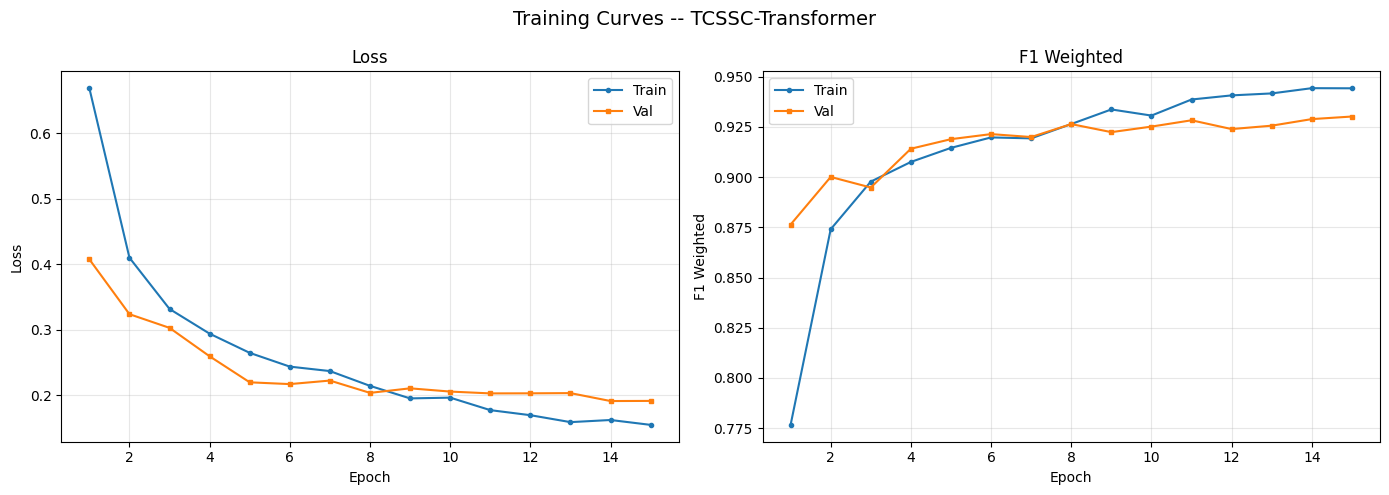

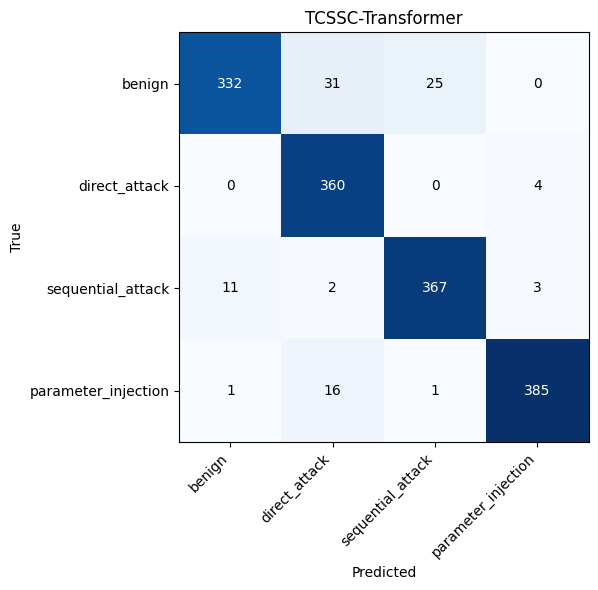

In [8]:
# EVALUASI FINAL -- TCSSC-Transformer

def load_best(model, agg_type):
    ckpt = os.path.join(CHECKPOINT_DIR, f'tcssc_{agg_type}_best.pt')
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    return model.to(DEVICE)

print('\n' + '='*60)
print('EVALUASI TCSSC-Transformer')
print('='*60)
model_transformer = load_best(TCSSC('transformer', freeze_bert=True), 'transformer')
res_transformer   = evaluate_final(model_transformer, test_loader, DEVICE)
asr_transformer   = compute_asr(model_transformer,    test_loader, DEVICE)
fpr_transformer   = compute_benign_fpr(model_transformer, test_loader, DEVICE)

acc = res_transformer['accuracy'] * 100
f1  = res_transformer['report']['weighted avg']['f1-score'] * 100
print(f"{'Model':<25} {'Accuracy':>10} {'F1 Weighted':>12} {'ASR (%)':>10} {'Benign FPR (%)':>15}")
print('-' * 60)
print(f"{'TCSSC-Transformer':<25} {acc:>9.2f}% {f1:>11.2f}% {asr_transformer:>9.2f}% {fpr_transformer:>14.2f}%")

# Training curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Curves -- TCSSC-Transformer', fontsize=14)
epochs = range(1, len(history_transformer['train_loss']) + 1)
axes[0].plot(epochs, history_transformer['train_loss'], label='Train', marker='o', ms=3)
axes[0].plot(epochs, history_transformer['val_loss'],   label='Val',   marker='s', ms=3)
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(epochs, history_transformer['train_f1'], label='Train', marker='o', ms=3)
axes[1].plot(epochs, history_transformer['val_f1'],   label='Val',   marker='s', ms=3)
axes[1].set_title('F1 Weighted'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('F1 Weighted')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves_transformer.png'), dpi=150)
plt.show()

# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
labels_names = list(LABEL2ID.keys())
cm = res_transformer['cm']
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.set_title('TCSSC-Transformer')
ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(labels_names, rotation=45, ha='right')
ax.set_yticklabels(labels_names)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'), ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix_transformer.png'), dpi=150)
plt.show()


## 9. ASR vs Baseline


ATTACK SUCCESS RATE (ASR) -- PERBANDINGAN
Baseline (tanpa detektor) : 58.6%
TCSSC-Transformer         : 1.04%  (reduksi 57.6pp)


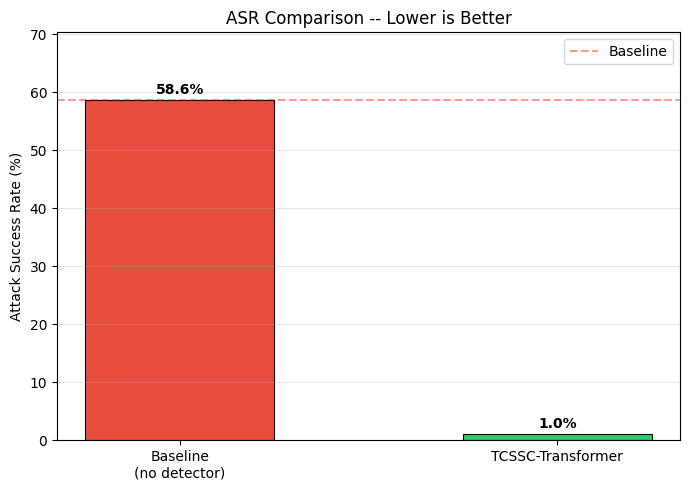


Hasil disimpan di /kaggle/working/outputs/


In [9]:
# ASR vs BASELINE -- TCSSC-Transformer
BASELINE_ASR = 58.6  # ASR STAC baseline (no detector)

print('\n' + '='*60)
print('ATTACK SUCCESS RATE (ASR) -- PERBANDINGAN')
print('='*60)
print(f'Baseline (tanpa detektor) : {BASELINE_ASR:.1f}%')
print(f'TCSSC-Transformer         : {asr_transformer:.2f}%  '
      f'(reduksi {BASELINE_ASR - asr_transformer:.1f}pp)')

fig, ax = plt.subplots(figsize=(7, 5))
models  = ['Baseline\n(no detector)', 'TCSSC-Transformer']
asrs    = [BASELINE_ASR, asr_transformer]
colors  = ['#e74c3c', '#2ecc71']
bars    = ax.bar(models, asrs, color=colors, width=0.5, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, asrs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('Attack Success Rate (%)')
ax.set_title('ASR Comparison -- Lower is Better')
ax.set_ylim(0, max(asrs) * 1.2)
ax.axhline(BASELINE_ASR, color='red', linestyle='--', alpha=0.4, label='Baseline')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'asr_comparison_transformer.png'), dpi=150)
plt.show()

summary = {
    'TCSSC-Transformer': {
        'accuracy': float(res_transformer['accuracy']),
        'f1_weighted': float(res_transformer['report']['weighted avg']['f1-score']),
        'asr': float(asr_transformer),
        'benign_fpr': float(fpr_transformer),
    },
}
with open(os.path.join(OUTPUT_DIR, 'results_summary_transformer.json'), 'w') as f:
    json.dump(summary, f, indent=2)
print('\nHasil disimpan di /kaggle/working/outputs/')
